In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [33]:
df = pd.read_csv("/content/online_retail.csv", encoding='latin1')

df.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,01-12-2010 08:34,4.25,13047.0,United Kingdom


In [30]:
df.columns

Index(['Description', 'Quantity', 'Price', 'Customer ID', 'Invoice', 'Country',
       'InvoiceDate', 'Year', 'Month', 'Day'],
      dtype='object')

In [14]:
df = df[['Description','Quantity','Price','Customer ID','Invoice','Country','InvoiceDate']]

df.columns = ['Description','Quantity','Price','Customer ID','Invoice','Country','InvoiceDate']

In [15]:
df = df.dropna()

In [16]:
df.columns

Index(['Description', 'Quantity', 'Price', 'Customer ID', 'Invoice', 'Country',
       'InvoiceDate'],
      dtype='object')

In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%d-%m-%Y %H:%M")

In [20]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Description'] = le.fit_transform(df['Description'])
df['Country'] = le.fit_transform(df['Country'])
df['Invoice'] = le.fit_transform(df['Invoice'])

In [25]:
df = df.dropna()

In [26]:
X = df[['Description','Quantity','Customer ID','Invoice','Country','Year','Month','Day']]
y = df['Price']

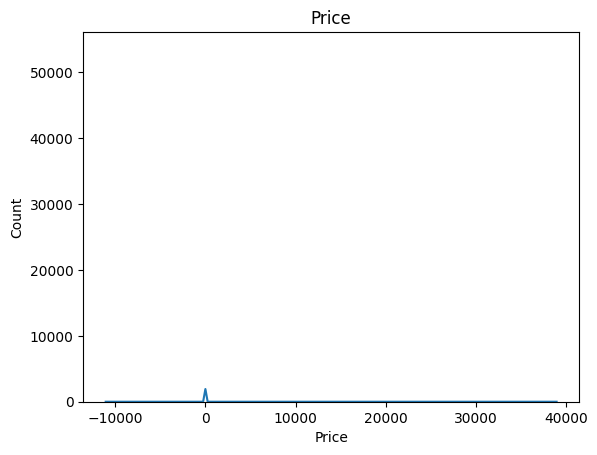

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Re-defining df to ensure it's available for this cell
df = pd.read_csv("/content/online_retail.csv", encoding='latin1')

sns.histplot(df["Price"], kde=True)
plt.title("Price")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
mae = mean_absolute_error(y_test, pred_lr)
r2 = r2_score(y_test, pred_lr)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 27.698645558837853
MAE: 2.863127181499296
R2 Score: 0.00030652291039723334


In [5]:
from google.colab import files
files.download("price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>